In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub

In [3]:
df = pd.read_csv("wine-reviews.csv", usecols = ['country', 'description', 'points', 'price', 'variety', 'winery'])

In [4]:
df.head()

,country,description,points,price,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",87,NaN,White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,15.0,Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",87,14.0,Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",87,13.0,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",87,65.0,Pinot Noir,Sweet Cheeks


In [5]:
df = df.dropna(subset = ["description", "points"])

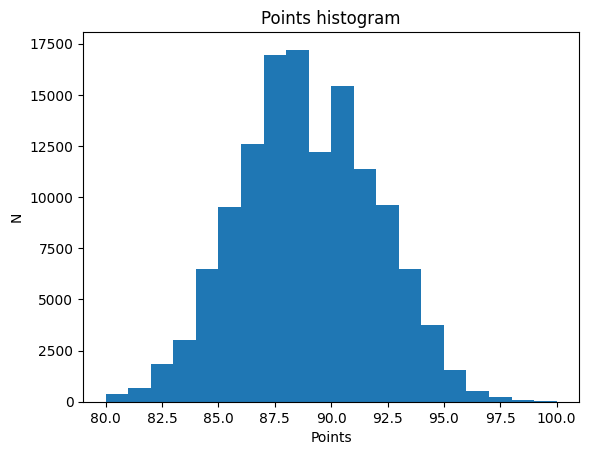

In [6]:
plt.hist(df.points, bins = 20)
plt.title("Points histogram")
plt.ylabel("N")
plt.xlabel("Points")
plt.show()

In [10]:
df["label"] = (df.points >= 90).astype(int)
df = df[["description", "label"]]

<ipython-input-10-372e38938b0a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = (df.points >= 90).astype(int)


In [12]:
df.tail()

,description,label
129966,Notes of honeysuckle and cantaloupe sweeten th...,1
129967,Citation is given as much as a decade of bottl...,1
129968,Well-drained gravel soil gives this wine its c...,1
129969,"A dry style of Pinot Gris, this is crisp with ...",1
129970,"Big, rich and off-dry, this is powered by inte...",1


In [20]:
train, val, test = np.split(df.sample(frac=1), [int(0.8*len(df)), int(0.9*len(df))])

In [21]:
len(train), len(val), len(test)

(103976, 12997, 12998)

In [22]:
def df_to_dataset(dataframe, shuffle=True, batch_size=1024):
  df = dataframe.copy()
  labels = df.pop('label')
  df = df["description"]
  ds = tf.data.Dataset.from_tensor_slices((df, labels))
  if shuffle:
    ds=ds.shuffle(buffer_size=len(dataframe))
  ds = ds.batch(batch_size)
  ds = ds.prefetch(tf.data.AUTOTUNE)
  return ds

In [32]:
train_data = df_to_dataset(train)
val_data = df_to_dataset(val)
test_data = df_to_dataset(test)

In [33]:
list(train_data)[0]

(<tf.Tensor: shape=(1024,), dtype=string, numpy=
 array([b"Subdued florals and apple scents have a slightly dusty, chemical edge on the nose of Mazza's Reserve Pinot Grigio. Slight in body but it finishes briskly on the palate. Drink now.",
        b'Funky, yeasty aromas seem forced and unnatural. This has a sketchy build and a flabby mouthfeel, while dry, melony flavors turn mildly bitter on the finish.',
        b'Featuring a voluptuous nose of stone fruit and citrus framed by roasted nuts and toasty oak, this is a rich, amply endowed Chardonnay with a big personality and bold flavors. Ripe peach notes join with citrus, hazelnuts and toast on the long finish. Drink now.',
        ...,
        b"Aromas of herbs, dates and licorice lead to reserved, silky-feeling flavors that show multiple layers and detail on this blend of Cabernet Sauvignon (59%), Merlot (26%) and Cabernet Franc. It's only ramps up with additional time in the glass.",
        b"Very fruity but nice and dry, this wine

#Embedding + Model

In [47]:
embedding = "https://tfhub.dev/google/nnlm-en-dim50/2"
hub_layer = hub.KerasLayer(embedding, dtype=tf.string, trainable=True)

In [48]:
hub_layer(list(train_data)[0][0])

<tf.Tensor: shape=(1024, 50), dtype=float32, numpy=
array([[ 0.32979298, -0.33773857, -0.14453296, ...,  0.06944194,
        -0.04418135, -0.12354085],
       [ 0.41706103, -0.13278855, -0.1607195 , ..., -0.12624273,
        -0.02248954, -0.04034702],
       [ 0.5987606 , -0.5481217 , -0.02374036, ...,  0.13119417,
         0.08664282, -0.03171137],
       ...,
       [ 0.35147437, -0.10148923,  0.01535594, ...,  0.04449613,
        -0.24077958,  0.0721783 ],
       [ 0.63642085, -0.26452696, -0.14721093, ..., -0.1196078 ,
         0.13210991, -0.19246444],
       [ 0.43515337, -0.1503976 ,  0.06768513, ...,  0.01162831,
        -0.15668026,  0.17047924]], dtype=float32)>

In [49]:
model = tf.keras.Sequential()
model.add(hub_layer)
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dropout(0.4))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dropout(0.4))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

In [50]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

In [51]:
model.evaluate(train_data)

102/102 [==============================] - 3s 21ms/step - loss: 0.6912 - accuracy: 0.5394


[0.6912217736244202, 0.539432168006897]

In [52]:
model.evaluate(val_data)

13/13 [==============================] - 0s 21ms/step - loss: 0.6913 - accuracy: 0.5399


[0.6912869215011597, 0.5398938059806824]

In [53]:
history = model.fit(train_data, epochs=5, validation_data=val_data)

Epoch 1/5
102/102 [==============================] - 143s 1s/step - loss: 0.6435 - accuracy: 0.6223 - val_loss: 0.5407 - val_accuracy: 0.7555
Epoch 2/5
102/102 [==============================] - 140s 1s/step - loss: 0.4858 - accuracy: 0.7654 - val_loss: 0.4008 - val_accuracy: 0.8186
Epoch 3/5
102/102 [==============================] - 137s 1s/step - loss: 0.4048 - accuracy: 0.8236 - val_loss: 0.3738 - val_accuracy: 0.8284
Epoch 4/5
102/102 [==============================] - 138s 1s/step - loss: 0.3686 - accuracy: 0.8417 - val_loss: 0.3715 - val_accuracy: 0.8312
Epoch 5/5
102/102 [==============================] - 138s 1s/step - loss: 0.3449 - accuracy: 0.8541 - val_loss: 0.3710 - val_accuracy: 0.8308


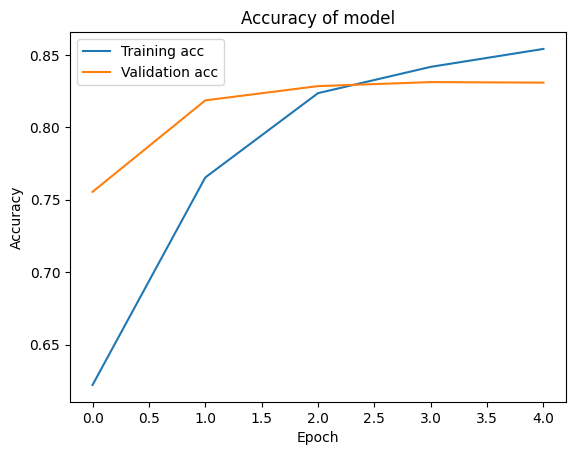

In [54]:
plt.plot(history.history['accuracy'], label = "Training acc")
plt.plot(history.history['val_accuracy'], label = "Validation acc")
plt.title("Accuracy of model")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

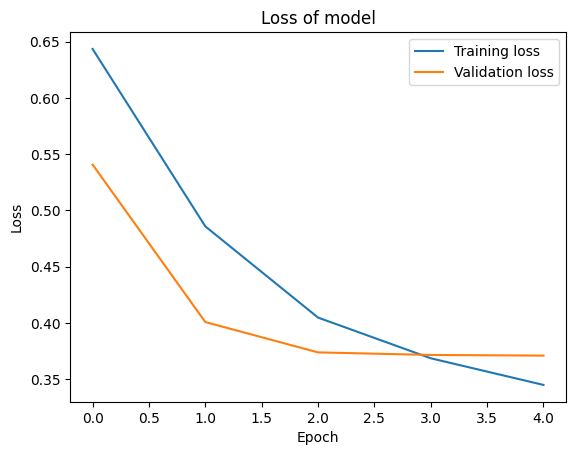

In [55]:
plt.plot(history.history['loss'], label = "Training loss")
plt.plot(history.history['val_loss'], label = "Validation loss")
plt.title("Loss of model")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [56]:
model.evaluate(test_data)

13/13 [==============================] - 3s 195ms/step - loss: 0.3822 - accuracy: 0.8301


[0.3822486698627472, 0.8300507664680481]

LSTM

In [58]:
encoder = tf.keras.layers.TextVectorization(max_tokens=2000)
encoder.adapt(train_data.map(lambda text, label:text))

In [59]:
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'and', 'the', 'a', 'of', 'with', 'this', 'is', 'wine',
       'flavors', 'in', 'it', 'to', 'its', 'on', 'fruit', 'aromas',
       'palate', 'that'], dtype='<U17')

In [64]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=32,
        mask_zero=True
    ),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [65]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

In [66]:
model.evaluate(train_data)

102/102 [==============================] - 25s 207ms/step - loss: 0.6932 - accuracy: 0.4872


[0.6932321190834045, 0.4871893525123596]

In [67]:
model.evaluate(val_data)

13/13 [==============================] - 2s 149ms/step - loss: 0.6932 - accuracy: 0.4861


[0.6931927800178528, 0.48611217737197876]

In [69]:
history = model.fit(train_data, epochs=5, validation_data=val_data)

Epoch 1/5
102/102 [==============================] - 42s 408ms/step - loss: 0.4942 - accuracy: 0.7500 - val_loss: 0.3611 - val_accuracy: 0.8360
Epoch 2/5
102/102 [==============================] - 46s 450ms/step - loss: 0.3599 - accuracy: 0.8394 - val_loss: 0.3528 - val_accuracy: 0.8367
Epoch 3/5
102/102 [==============================] - 42s 410ms/step - loss: 0.3471 - accuracy: 0.8460 - val_loss: 0.3442 - val_accuracy: 0.8416
Epoch 4/5
102/102 [==============================] - 41s 401ms/step - loss: 0.3417 - accuracy: 0.8473 - val_loss: 0.3424 - val_accuracy: 0.8433
Epoch 5/5
102/102 [==============================] - 42s 407ms/step - loss: 0.3373 - accuracy: 0.8490 - val_loss: 0.3513 - val_accuracy: 0.8370


In [70]:
model.evaluate(test_data)

13/13 [==============================] - 2s 138ms/step - loss: 0.3610 - accuracy: 0.8331


[0.3609740734100342, 0.8331281542778015]